In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.cm as cm

plt.style.use("seaborn-v0_8-darkgrid")
PALETTE = [cm.viridis(i) for i in np.linspace(0, 0.85, 5)]
ITEM_PALETTE = [cm.viridis(0.1), cm.viridis(0.5), cm.viridis(0.9)]

### Data dictionary: bid level df

| Column name | Data type | Description |
| :--- | :--- | :--- |
| **auction_id** | `int` | Unique identifier for each specific auction event. |
| **bid** | `float` | The value of the specific bid entered by the bidder. |
| **bid_time** | `float` | Time passed (in days) since the auction started. |
| **bidder** | `object` | Anonymized username or ID of the person placing the bid. |
| **bidder_rate**| `float` | The feedback rating of the bidder (proxy for experience). |
| **open_bid** | `float` | The starting price set by the seller. |
| **hammer_price** | `float` | The final selling price of the item (the winning bid). |
| **item** | `object` | Category or name of the object being auctioned (e.g., Cartier wristwatch). |
| **auction_type** | `object` | The duration of the auction (e.g., "3 day auction"). |
| **duration_days** | `int`| **(Engineered)** The total length of the auction extracted as a numeric value. |
| **relative_bid_time**| `float` | **(Engineered)** Bid time as a % of total duration (0.0 = start, 1.0 = end). |
| **bid_increment** | `float` | **(Engineered)** The "jump" in price from the previous bid in that auction. |
| **is_winner** | `bool` | **(Engineered)** True if this specific row represents the winning bid. |
| **is_snipe** | `bool` | **(Engineered)** True if the bid was placed in the final 5% of the auction time. |

In [2]:
auction_df = pd.read_csv("../data/auction.csv")

auction_df.head()

,auctionid,bid,bidtime,bidder,bidderrate,openbid,price,item,auction_type
0,1638893549,175.0,2.230949,schadenfreud,0.0,99.0,177.5,Cartier wristwatch,3 day auction
1,1638893549,100.0,2.600116,chuik,0.0,99.0,177.5,Cartier wristwatch,3 day auction
2,1638893549,120.0,2.600810,kiwisstuff,2.0,99.0,177.5,Cartier wristwatch,3 day auction
3,1638893549,150.0,2.601076,kiwisstuff,2.0,99.0,177.5,Cartier wristwatch,3 day auction
4,1638893549,177.5,2.909826,eli.flint@flightsafety.co,4.0,99.0,177.5,Cartier wristwatch,3 day auction


In [3]:
print(auction_df.shape)
auction_df.dtypes

(10681, 9)


auctionid         int64
bid             float64
bidtime         float64
bidder              str
bidderrate      float64
openbid         float64
price           float64
item                str
auction_type        str
dtype: object

In [4]:
print(f"Total duplicates: {auction_df.duplicated().sum()}")

print("\nTotal missing values:\n\n", auction_df.isna().sum())

Total duplicates: 0

Total missing values:

 auctionid        0
bid              0
bidtime          0
bidder          16
bidderrate      11
openbid          0
price            0
item             0
auction_type     0
dtype: int64


In [5]:
auction_df_clean = auction_df.copy()

auction_df_clean["bidder"] = auction_df_clean["bidder"].fillna("Unknown")

# Using 0 for bidderrate (assuming new/guest user)
auction_df_clean["bidderrate"] = auction_df_clean["bidderrate"].fillna(0)

print("Total missing values:\n\n", auction_df_clean.isna().sum())

Total missing values:

 auctionid       0
bid             0
bidtime         0
bidder          0
bidderrate      0
openbid         0
price           0
item            0
auction_type    0
dtype: int64


In [6]:
auction_df_clean = auction_df_clean.rename(columns = {
    "auctionid": "auction_id",
    "bidtime": "bid_time",
    "bidderrate": "bidder_rate", 
    "openbid": "open_bid",
    "price": "hammer_price"
})

auction_df_clean.head()

,auction_id,bid,bid_time,bidder,bidder_rate,open_bid,hammer_price,item,auction_type
0,1638893549,175.0,2.230949,schadenfreud,0.0,99.0,177.5,Cartier wristwatch,3 day auction
1,1638893549,100.0,2.600116,chuik,0.0,99.0,177.5,Cartier wristwatch,3 day auction
2,1638893549,120.0,2.600810,kiwisstuff,2.0,99.0,177.5,Cartier wristwatch,3 day auction
3,1638893549,150.0,2.601076,kiwisstuff,2.0,99.0,177.5,Cartier wristwatch,3 day auction
4,1638893549,177.5,2.909826,eli.flint@flightsafety.co,4.0,99.0,177.5,Cartier wristwatch,3 day auction


In [7]:
print(auction_df_clean["item"].unique())
print(auction_df_clean["auction_type"].unique())

<StringArray>
['Cartier wristwatch', 'Palm Pilot M515 PDA', 'Xbox game console']
Length: 3, dtype: str
<StringArray>
['3 day auction', '5 day auction', '7 day auction']
Length: 3, dtype: str


In [8]:
auction_df_clean["auction_duration_days"] = auction_df_clean["auction_type"].str.extract(r"(\d+)").astype(int)

auction_df_clean["relative_bid_time"] = auction_df_clean["bid_time"] / auction_df_clean["auction_duration_days"]

auction_df_clean.head(3)

,auction_id,bid,bid_time,bidder,bidder_rate,open_bid,hammer_price,item,auction_type,auction_duration_days,relative_bid_time
0,1638893549,175.0,2.230949,schadenfreud,0.0,99.0,177.5,Cartier wristwatch,3 day auction,3,0.743650
1,1638893549,100.0,2.600116,chuik,0.0,99.0,177.5,Cartier wristwatch,3 day auction,3,0.866705
2,1638893549,120.0,2.600810,kiwisstuff,2.0,99.0,177.5,Cartier wristwatch,3 day auction,3,0.866937


In [9]:
# Adding bid momentum for each auction
auction_df_clean = auction_df_clean.sort_values(["auction_id", "bid_time"])
auction_df_clean["bid_increment"] = auction_df_clean.groupby("auction_id")["bid"].diff().fillna(0)


# Flagging winner
auction_df_clean["is_winner"] = auction_df_clean["bid"] == auction_df_clean["hammer_price"]


# A bid is a snipe if it happens in the final 5% of the auction 
auction_df_clean["is_snipe"] = auction_df_clean["relative_bid_time"] > 0.95

In [10]:
snipe_percentage = auction_df_clean["is_snipe"].mean() * 100
print(f"Percentage of bids that are 'Snipes': {snipe_percentage:.2f}%")

Percentage of bids that are 'Snipes': 32.10%


In [11]:
auction_df_clean.describe()

,auction_id,bid,bid_time,bidder_rate,open_bid,hammer_price,auction_duration_days,relative_bid_time,bid_increment
count,1.068100e+04,10681.000000,10681.000000,10681.000000,10681.000000,10681.000000,10681.000000,10681.000000,10681.000000
mean,4.136148e+09,207.586109,3.979628,31.903848,52.246256,335.043589,5.939612,0.670505,11.574572
std,2.489918e+09,323.037396,2.353386,120.536308,168.453245,433.566009,1.584867,0.339510,68.624678
min,1.638844e+09,0.010000,0.000567,-4.000000,0.010000,26.000000,3.000000,0.000081,-1080.000000
25%,3.015329e+09,72.000000,1.949931,1.000000,1.000000,186.510000,5.000000,0.361319,0.000000
50%,3.020526e+09,140.000000,4.140833,5.000000,4.990000,228.490000,7.000000,0.821879,5.000000
75%,8.212136e+09,210.000000,6.448060,21.000000,50.000000,255.000000,7.000000,0.974873,15.000000
max,8.215611e+09,5400.000000,6.999990,3140.000000,5000.000000,5400.000000,7.000000,0.999999,1150.000000


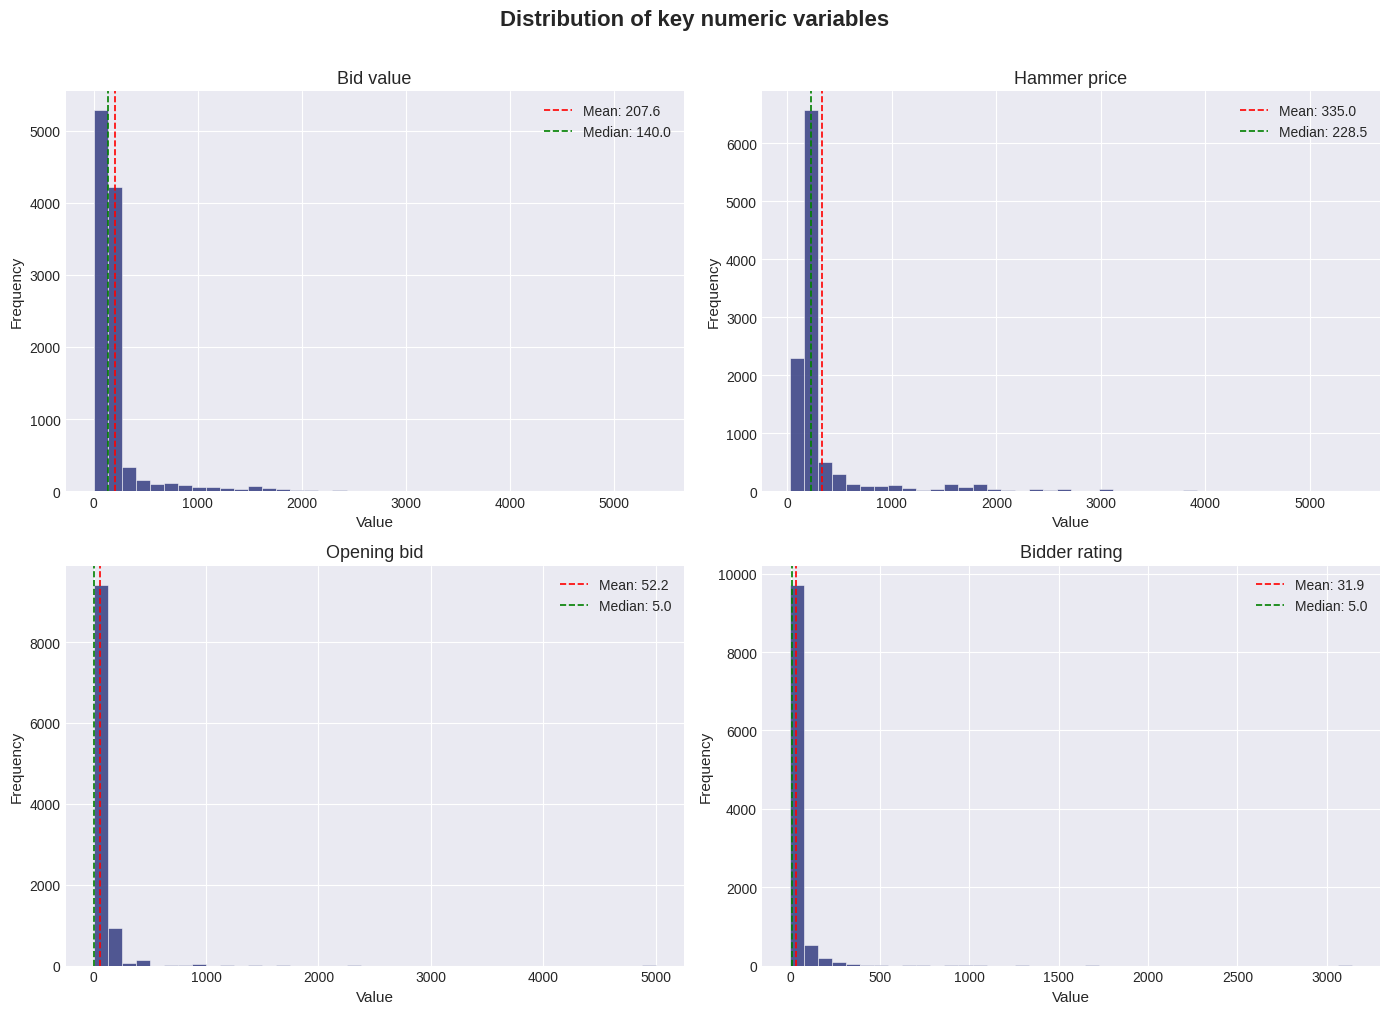

In [12]:
fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle("Distribution of key numeric variables", fontsize=16, fontweight="bold", y=1.01)

cols = {
    "bid": "Bid value",
    "hammer_price": "Hammer price",
    "open_bid": "Opening bid",
    "bidder_rate": "Bidder rating"
}

for ax, (col, label) in zip(axes.flatten(), cols.items()):
    data = auction_df_clean[col]

    ax.hist(data, bins=40, color=PALETTE[1], edgecolor="white", linewidth=0.4, alpha=0.9)
    ax.axvline(data.mean(), color="red", linestyle="--", linewidth=1.2, label=f"Mean: {data.mean():.1f}")
    ax.axvline(data.median(), color="green", linestyle="--", linewidth=1.2, label=f"Median: {data.median():.1f}")

    ax.set_title(label, fontsize=13)
    ax.set_xlabel("Value", fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../img/01_distributions.png")
plt.show()

`bid`, `hammer_price` and `open_bid` show strong right skew, a small number of high-value items pulling the tail: most items cluster in a low-price range, but outliers drive disproportionate revenue.  

`bidder_rate` is heavily skewed meaning most of the bidders are new and have low experience, but few highly experienced ones pull the tail.

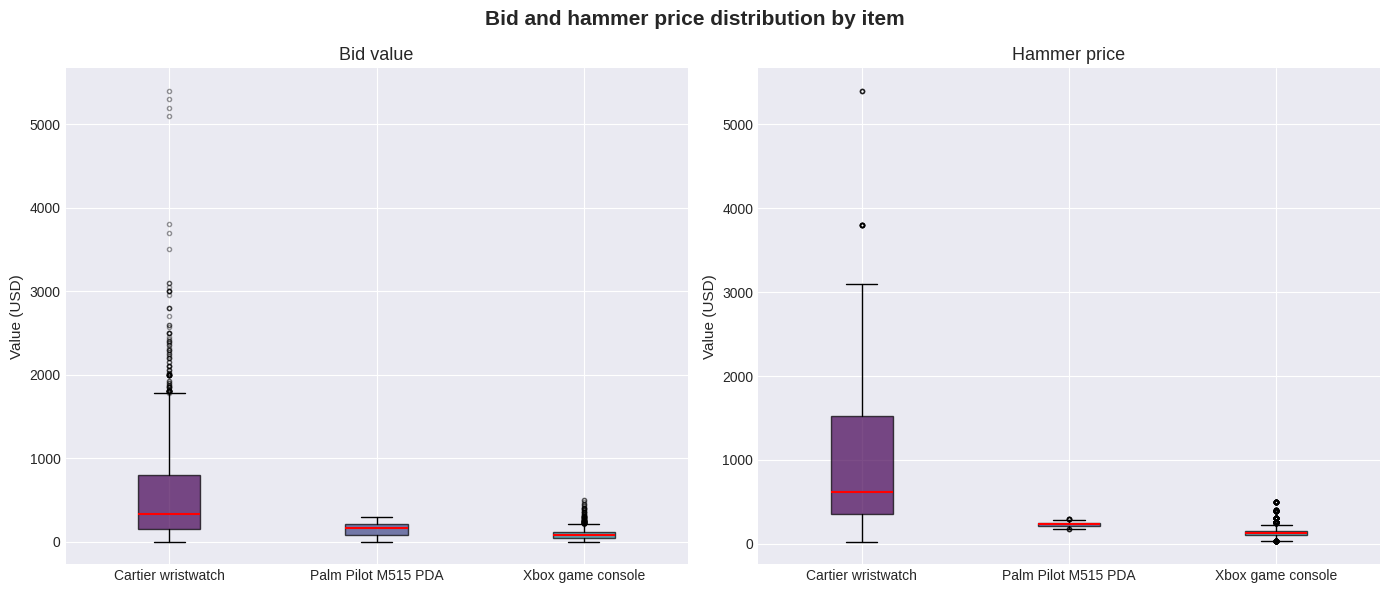

In [13]:
fig2, axes = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle("Bid and hammer price distribution by item", fontsize=15, fontweight="bold")

for ax, col, label in zip(axes, ["bid", "hammer_price"], ["Bid value", "Hammer price"]):
    data = [
        auction_df_clean[auction_df_clean["item"] == item][col].values
        for item in auction_df_clean["item"].unique()
    ]

    bp = ax.boxplot(
        data,
        tick_labels=auction_df_clean["item"].unique(),
        patch_artist=True,
        flierprops=dict(marker="o", markersize=3, alpha=0.4),
        medianprops=dict(color="red", linewidth=1.5)
    )

    for patch, color in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(label, fontsize=13)
    ax.set_ylabel("Value (USD)", fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=10)

plt.tight_layout()
plt.savefig("../img/02_boxplots.png")
plt.show()

The Cartier boxplot sitting higher on the hammer price chart means the floor of a typical Cartier auction outcome is already above the ceiling of a typical Palm Pilot or Xbox sale. It's not just that Cartier has outliers, even its interquartile range doesn't overlap much with the other two items. 

The `bid value` vs. `hammer price` comparison also reveals something subtle: Cartier's bid box is relatively compressed (median ~400) but the hammer price box is much taller and higher. That suggests competitive escalation, auctions starting modestly but getting driven up significantly by bidding wars. The Palm Pilot and Xbox show much tighter bid-to-hammer relationships, indicating more predictable, lower-competition outcomes.

Follow up questions:  
Does Cartier also attract more bidders per auction, explaining that escalation?
Do Cartier auctions snipe more: are those outlier hammer prices driven by last-minute bids?
Is the realization ratio (hammer/open) highest for Cartier, confirming it as the highest "market heat" category?

In [14]:
# Creating a df with auction level data
auction_level_df = auction_df_clean.groupby("auction_id").apply(
    lambda g: pd.Series({
        # Auction identity
        "item":                   g["item"].iloc[0],
        "auction_type":           g["auction_type"].iloc[0],
        "auction_duration_days":  g["auction_duration_days"].iloc[0],

        # Pricing
        "open_bid":               g["open_bid"].iloc[0],
        "hammer_price":           g["hammer_price"].iloc[0],
        "realization_ratio":      g["hammer_price"].iloc[0] / g["open_bid"].iloc[0],

        # Bid volume
        "n_bids":                 len(g),
        "n_bidders":              g["bidder"].nunique(),
        "n_snipe_bids":           g["is_snipe"].sum(),
        "single_bidder_flag":     g["bidder"].nunique() == 1,

        # Bid increments
        "max_bid_increment":      g["bid_increment"].max(),
        "std_bid_increment":      g["bid_increment"].std(), # how erratic the bidding was

        # Bidder experience
        "mean_bidder_rate":       g["bidder_rate"].mean(),
        "max_bidder_rate":        g["bidder_rate"].max(),

        # Timing
        "first_bid_time":         g["bid_time"].min(),
        "active_window":          g["bid_time"].max() - g["bid_time"].min(),

        # Repeat bidders
        "n_repeat_bidders":       (g.groupby("bidder").size() > 1).sum(),

        # Winner profile
        "winner_sniped":          g.loc[g["is_winner"], "is_snipe"].values[0] if g["is_winner"].any() else np.nan,
        "winner_bidder_rate":     g.loc[g["is_winner"], "bidder_rate"].values[0] if g["is_winner"].any() else np.nan
    })
).reset_index()

auction_level_df.head()

,auction_id,item,auction_type,auction_duration_days,open_bid,hammer_price,realization_ratio,n_bids,n_bidders,n_snipe_bids,single_bidder_flag,max_bid_increment,std_bid_increment,mean_bidder_rate,max_bidder_rate,first_bid_time,active_window,n_repeat_bidders,winner_sniped,winner_bidder_rate
0,1638843936,Cartier wristwatch,7 day auction,7,500.0,1625.0,3.250000,7,5,2,False,900.0,359.935510,38.428571,181.0,0.478368,6.414745,1,True,5.0
1,1638844284,Cartier wristwatch,7 day auction,7,200.0,500.0,2.500000,2,2,0,False,275.0,194.454365,16.500000,33.0,1.237419,0.014988,0,False,33.0
2,1638844464,Cartier wristwatch,7 day auction,7,300.0,740.0,2.466667,16,5,13,False,145.0,55.905430,9.125000,58.0,1.811134,5.188611,3,True,5.0
3,1638844729,Cartier wristwatch,7 day auction,7,225.0,320.0,1.422222,11,2,10,False,85.0,32.641301,29.636364,82.0,6.121782,0.877431,2,True,82.0
4,1638893549,Cartier wristwatch,3 day auction,3,99.0,177.5,1.792929,5,4,1,False,30.0,43.817805,1.600000,4.0,2.230949,0.678877,1,True,4.0


## Data dictionary: auction-level df

| Column | Type | Description |
|---|---|---|
| `auction_id` | `int` | Unique identifier for each auction. |
| `item` | `str` | Item category being auctioned. |
| `auction_type` | `str` | Auction duration label (e.g. "7 day auction"). |
| `auction_duration_days` | `int` | Total length of the auction in days. |
| `open_bid` | `float` | The starting price set by the seller. |
| `hammer_price` | `float` | The final selling price. |
| `realization_ratio` | `float` | Measures how many times over the item sold relative to its starting price. |
| `n_bids` | `int` | Total number of bids placed in the auction. |
| `n_bidders` | `int` | Number of unique bidders who participated. |
| `n_snipe_bids` | `int` | Number of bids placed in the final 5% of the auction's duration. |
| `single_bidder_flag` | `bool` | True if only one unique bidder participated, indicates an uncontested auction. |
| `max_bid_increment` | `float` | The single largest price jump between consecutive bids. Flags moments of aggressive bidding. |
| `std_bid_increment` | `float` | Standard deviation of bid increments. A high value means erratic, burst-like bidding; a low value means steady escalation. NaN for single-bid auctions. |
| `mean_bidder_rate` | `float` | Average feedback score across all bidders in the auction. Used as a proxy for the general experience level of the participant pool. |
| `max_bidder_rate` | `float` | Highest individual feedback score in the auction. Captures the presence of highly experienced participants. |
| `first_bid_time` | `float` | Time in days from auction start to the first bid placed. |
| `active_window` | `float` | Time in days between the first and last bid. A near-zero value indicates all activity clustered at the end. |
| `n_repeat_bidders` | `int` | Number of bidders who placed more than one bid in the auction. Signals contested, back-and-forth competition. |
| `winner_sniped` | `bool` | True if the winning bid was placed in the final 5% of the auction. NaN if no winner is identified. |
| `winner_bidder_rate` | `float` | Feedback score of the winning bidder. Used to assess whether more experienced bidders win more often. NaN if no winner is identified. |
| `realization_ratio_capped` | `float` | Realization ratio capped at 50 to limit the influence of extreme outliers caused by near-zero opening bids. Used in place of the raw ratio for summary statistics and visualisations. |
| `snipe_rate` | `float` | Proportion of bids in the auction that qualify as snipes (n_snipe_bids / n_bids). |
| `open_bid_band` | `category` | Opening price grouped into four bands: Very low (0–50), Low (50–200), Mid (200–500), High (500+). Used for competition comparison across price tiers. |

In [15]:
auction_level_df["realization_ratio"].describe()

count       628.000000
mean       2939.047243
std        9654.810790
min           1.000000
25%           1.543523
50%           7.562800
75%         218.937500
max      160000.000000
Name: realization_ratio, dtype: float64

In [16]:
auction_level_df[auction_level_df["realization_ratio"] == auction_level_df["realization_ratio"].max()][
    ["auction_id", "item", "open_bid", "hammer_price", "realization_ratio"]
]

,auction_id,item,open_bid,hammer_price,realization_ratio
66,1644049270,Cartier wristwatch,0.01,1600.0,160000.0


In [17]:
auction_level_df["realization_ratio_capped"] = auction_level_df["realization_ratio"].clip(upper=50)

auction_level_df.describe()

,auction_id,auction_duration_days,open_bid,hammer_price,realization_ratio,n_bids,n_bidders,n_snipe_bids,max_bid_increment,std_bid_increment,mean_bidder_rate,max_bidder_rate,first_bid_time,active_window,n_repeat_bidders,winner_bidder_rate,realization_ratio_capped
count,6.280000e+02,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,607.000000,628.000000,628.000000,628.000000,628.000000,628.000000,626.000000,628.000000
mean,3.955072e+09,5.751592,109.344602,347.860127,2939.047243,17.007962,8.243631,5.460191,88.749825,37.345867,33.889265,212.917197,1.537621,4.043411,3.582803,40.102236,21.844529
std,2.438180e+09,1.681710,286.581602,481.398632,9654.810790,10.885877,4.577478,4.826496,152.391121,63.917768,46.728097,342.661819,1.950624,2.499504,2.422217,131.114310,22.055531
min,1.638844e+09,3.000000,0.010000,26.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000567,0.000000,0.000000,-4.000000,1.000000
25%,3.014747e+09,5.000000,1.000000,186.132500,1.543523,8.000000,4.000000,2.000000,20.000000,10.882920,9.767045,33.750000,0.135605,1.911849,2.000000,1.000000,1.543523
50%,3.020237e+09,7.000000,24.745000,227.500000,7.562800,16.000000,8.000000,4.000000,50.000000,19.532885,19.309524,103.500000,0.611175,4.365017,3.000000,6.500000,7.562800
75%,3.025793e+09,7.000000,150.000000,255.002500,218.937500,24.000000,12.000000,8.000000,85.000000,32.332732,38.446429,229.000000,2.227383,6.595810,5.000000,22.000000,50.000000
max,8.215611e+09,7.000000,5000.000000,5400.000000,160000.000000,75.000000,24.000000,34.000000,1150.000000,609.713047,497.500000,3140.000000,6.999390,6.999271,13.000000,1838.000000,50.000000


In [18]:
auction_level_df["single_bidder_flag"].sum()

np.int64(24)

In [19]:
auction_level_df[
    (auction_level_df["single_bidder_flag"] == True) & 
    (auction_level_df["std_bid_increment"].notna())
][["auction_id", "item", "n_bids", "n_bidders", "std_bid_increment"]]

,auction_id,item,n_bids,n_bidders,std_bid_increment
336,3021836029,Palm Pilot M515 PDA,8,1,0.00000
461,3025598698,Palm Pilot M515 PDA,2,1,0.00000
494,8212190120,Xbox game console,9,1,3.73742


## 1. Temporal behaviour (Sniping)

This section investigates *when* bids are placed relative to the auction's closing time. 

A **snipe bid** is defined as any bid placed in the final 5% of an auction's duration (`relative_bid_time > 0.95`). Across all 10.681 bids in the dataset, **32.1% qualify as snipes**.

The goal is to quantify last-minute bidding behaviour and assess whether it influences final sale prices. Three angles are explored: 
- the overall distribution of bid timing
- the relationship between sniping and hammer price
- snipe rates across item categories

**Implications**  
The concentration of bids in the final 5% of auction time is a strong argument for implementing a **soft-close** mechanism: automatically extending the auction when a bid is placed in the final minutes.   
This would encourage more competitive bidding throughout the auction and potentially improve final sale prices.

### Bid timing distribution
The histogram of relative bid time shows a clear and dramatic spike in activity as auctions approach their close. Bidding is otherwise sparse and relatively uniform throughout the auction, which suggests that many participants deliberately wait until the final moments before committing.
This "last minute rush" is a structural feature of the data, not an anomaly.

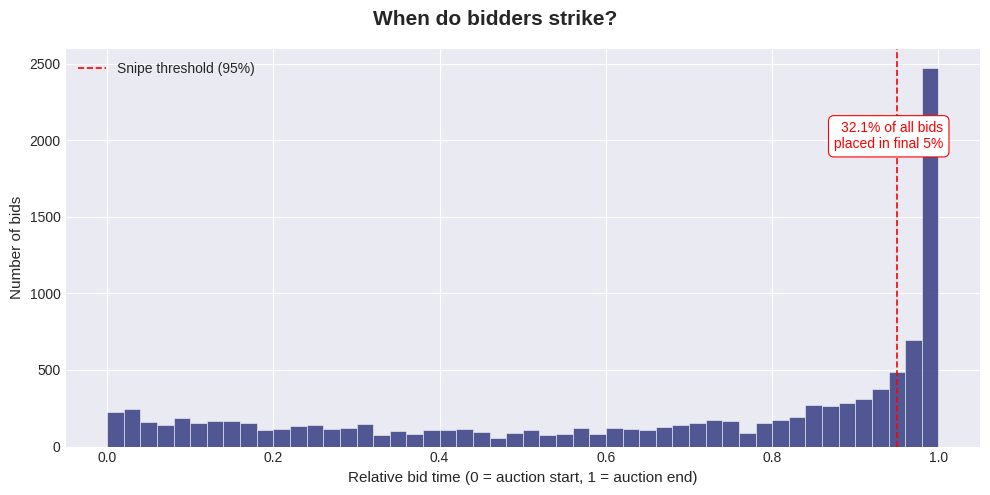

In [20]:
fig3, ax = plt.subplots(figsize=(10,5))
fig3.suptitle("When do bidders strike?", fontsize=15, fontweight="bold")

ax.hist(auction_df_clean["relative_bid_time"], bins=50, color=PALETTE[1], edgecolor="white", linewidth=0.4, alpha=0.9)

ax.axvline(0.95, color="red", linestyle="--", linewidth=1.2, label="Snipe threshold (95%)")

ax.text(
    0.96, 0.75,
    f"{snipe_percentage:.1f}% of all bids\nplaced in final 5%",
    transform=ax.transAxes,
    ha="right", fontsize=10,
    color="red",
    bbox=dict(boxstyle="round,pad=0.4", 
              facecolor="white", 
              edgecolor="red", 
              linewidth=0.8)
)

ax.set_xlabel("Relative bid time (0 = auction start, 1 = auction end)", fontsize=11)
ax.set_ylabel("Number of bids", fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../img/03_bid_timing_distribution.png")
plt.show()

### Do snipes drive higher prices?
Contrary to initial expectations, auctions won by a snipe bid do not produce higher hammer prices on average ($340 snipe win vs. $388 no snipe).  The difference of $48 is modest and likely reflects the item mix rather than a causal effect of sniping itself: higher value Cartier auctions tend to attract more deliberate, non-snipe bidding patterns

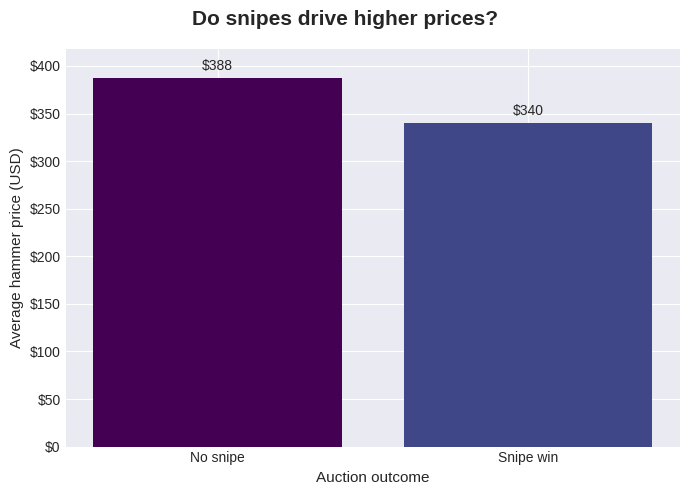

In [21]:
winner_sniper_hammer_price = auction_level_df.groupby("winner_sniped")["hammer_price"].mean()


fig4, ax = plt.subplots(figsize=(7, 5))
fig4.suptitle("Do snipes drive higher prices?", fontsize=15, fontweight="bold")

bars = ax.bar(
    ["No snipe", "Snipe win"], 
    winner_sniper_hammer_price.values,
    color=PALETTE)


for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_xlabel("Auction outcome", fontsize=11)
ax.set_ylabel("Average hammer price (USD)", fontsize=11)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_ylim(0, winner_sniper_hammer_price.max() + 30)

plt.tight_layout()
plt.savefig("../img/04_snipe_vs_hammer_price.png")
plt.show()

### Snipe rate by item
Snipe rates are broadly consistent across the three item categories, with no single category showing dramatically different last-minute behaviour. 
This suggests that sniping is a general bidding strategy in this marketplace rather than a category-specific one.

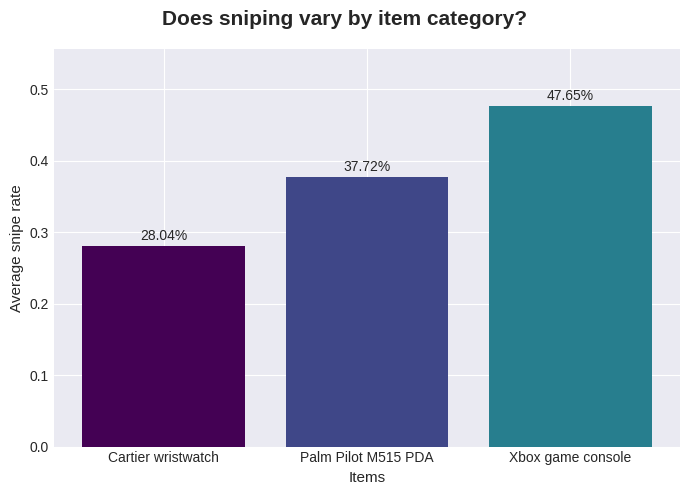

In [22]:
auction_level_df["snipe_rate"] = auction_level_df["n_snipe_bids"] / auction_level_df["n_bids"]
grouped_items_vs_snipe_rate = auction_level_df.groupby("item")["snipe_rate"].mean()


fig5, ax = plt.subplots(figsize=(7, 5))
fig5.suptitle("Does sniping vary by item category?", fontsize=15, fontweight="bold")

bars = ax.bar(
    grouped_items_vs_snipe_rate.index, 
    grouped_items_vs_snipe_rate.values,
    color=PALETTE)


for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.2%}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_xlabel("Items", fontsize=11)
ax.set_ylabel("Average snipe rate", fontsize=11)
ax.set_ylim(0, grouped_items_vs_snipe_rate.max() + 0.08)

plt.tight_layout()
plt.savefig("../img/05_snipe_rate_by_item.png")
plt.show()

## 2. Price discovery and estimates

This section examines whether the opening price influences the final outcome of an auction. The central question is:  
*Do lower starting prices lead to more competitive bidding and higher returns?*   

Four angles are explored:   
- the relationship between opening and hammer price  
- the relationship between opening and realization ratio as a normalised measure of return  
- opening price bands as a direct competition test  
- correlation matrix to quantify all relationships simultaneously.  

### Does the opening price shape the final outcome?

In the plots, each point represents one auction, coloured by item category. The left panel plots the raw relationship between opening and hammer price, while the right normalises for item value by using the realization ratio instead.  

Together they show that Cartier auctions show wide dispersion in both panels, reflecting a high-variance, unpredictable market, while Xbox and Palm Pilot cluster tightly in the low-value corner.  

The right panel makes the key pattern visible: auctions with very low opening bids scatter across the full range of realization ratios, while high opening bids consistently produce ratios close to 1. A low starting price creates the conditions for high returns, but does not guarantee them.

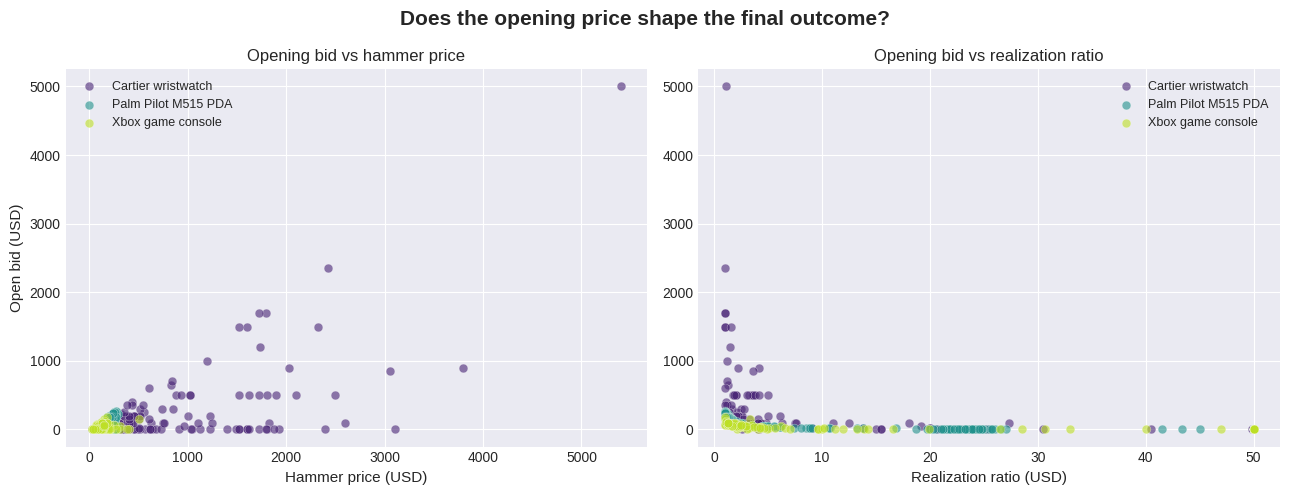

In [23]:
fig6, axes = plt.subplots(1, 2, figsize=(13, 5))
fig6.suptitle("Does the opening price shape the final outcome?", fontsize=15, fontweight="bold")

items = auction_level_df["item"].unique()


for item, color in zip(items, ITEM_PALETTE):
    subset = auction_level_df[auction_level_df["item"] == item]
    axes[0].scatter(
        subset["hammer_price"],
        subset["open_bid"],
        label=item,
        color=color,
        alpha=0.6,
        edgecolors="white",
        linewidths=0.3,
        s=40
    )

axes[0].set_title("Opening bid vs hammer price", fontsize=12)
axes[0].set_xlabel("Hammer price (USD)", fontsize=11)
axes[0].set_ylabel("Open bid (USD)", fontsize=11)
axes[0].legend(fontsize=9)

# ---

for item, color in zip(items, ITEM_PALETTE):
    subset = auction_level_df[auction_level_df["item"] == item]
    axes[1].scatter(
        subset["realization_ratio_capped"],
        subset["open_bid"],
        label=item,
        color=color,
        alpha=0.6,
        edgecolors="white",
        linewidths=0.3,
        s=40
    )

axes[1].set_title("Opening bid vs realization ratio", fontsize=12)
axes[1].set_xlabel("Realization ratio (USD)", fontsize=11)
axes[1].legend(fontsize=9)


plt.tight_layout()
plt.savefig("../img/06_open_bid_scatter.png")
plt.show()

### Does opening price affect competition and returns?
To test the hypothesis directly, auctions are grouped into four opening price bands and compared across three competition metrics.  

Very low opening bids (under $50) attract nearly 3x more bidders, generate 22.8 bids on average and achieve a mean realization ratio of 36 - compared to 1.5–2.2 for all other bands. This is the strongest evidence in the analysis that conservative starting prices drive competitive escalation.

*Note: the very low band represents 58% of all auctions in the dataset and extreme realization ratios are partly a mathematical artifact of near-zero opening bids.*

In [24]:
# Define price bands
bins = [0, 50, 200, 500, np.inf]
labels = ["Very low (0-50)", "Low (50-200)", "Mid (200-500)", "High (500+)"]

auction_level_df["open_bid_band"] = pd.cut(
    auction_level_df["open_bid"],
    bins=bins,
    labels=labels
)

# Aggregate by band
price_bands = auction_level_df.groupby("open_bid_band", observed=True).agg(
    n_auctions        = ("auction_id", "count"),
    avg_n_bidders     = ("n_bidders", "mean"),
    avg_n_bids        = ("n_bids", "mean"),
    avg_realization   = ("realization_ratio_capped", "mean")
).reset_index()

print(price_bands)

     open_bid_band  n_auctions  avg_n_bidders  avg_n_bids  avg_realization
0  Very low (0-50)         366      10.841530   22.775956        36.052905
1     Low (50-200)         181       5.287293   10.259669         2.212467
2    Mid (200-500)          66       2.984848    5.727273         1.492764
3      High (500+)          15       3.666667    7.333333         1.601461


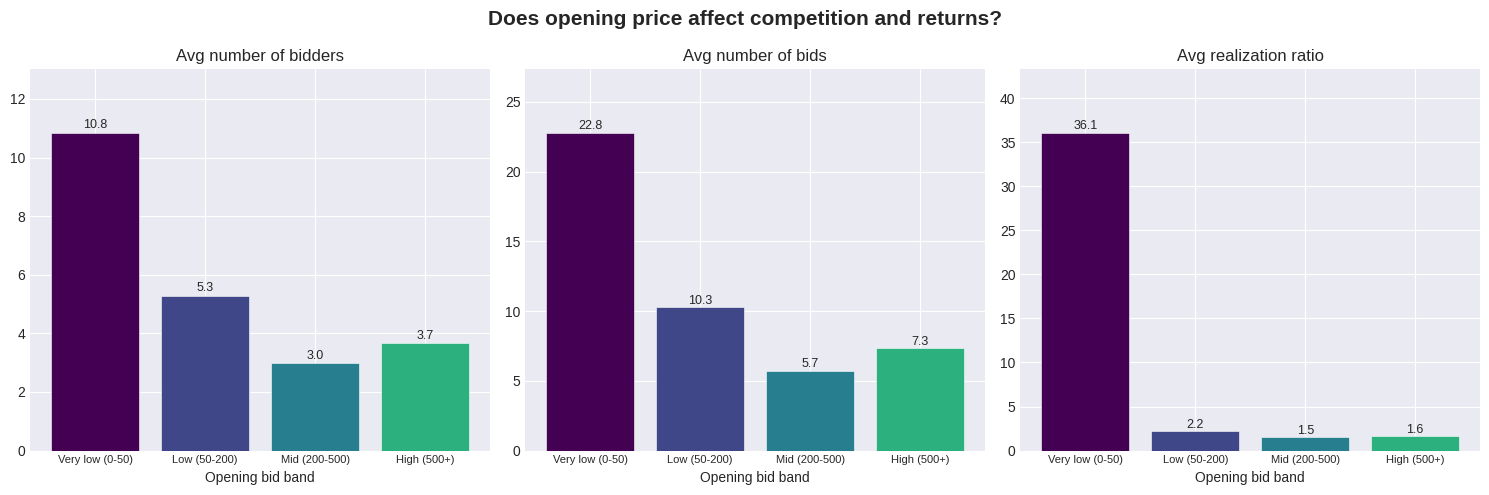

In [25]:
metrics = {
    "avg_n_bidders":   "Avg number of bidders",
    "avg_n_bids":      "Avg number of bids",
    "avg_realization": "Avg realization ratio"
}

fig7, axes = plt.subplots(1, 3, figsize=(15, 5))
fig7.suptitle("Does opening price affect competition and returns?", fontsize=15, fontweight="bold")

for ax, (metric, label) in zip(axes, metrics.items()):
    bars = ax.bar(
        price_bands["open_bid_band"],
        price_bands[metric],
        color=PALETTE[:len(price_bands)],
        edgecolor="white",
        linewidth=0.4
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.05,
            f"{height:.1f}",
            ha="center", va="bottom", fontsize=9
        )

    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Opening bid band", fontsize=10)
    ax.set_ylim(0, price_bands[metric].max() * 1.2)
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.savefig("../img/07_price_bands.png")
plt.show()

### Correlation matrix
The correlation matrix quantifies all relationships simultaneously.  
The `open_bid` row confirms the hypothesis numerically: opening price is negatively correlated with `realization_ratio` (-0.34), number of `bidders` (-0.34), and number of bids (-0.31). A competition cluster emerges between `n_bidders`, `n_bids`, `realization_ratio_capped` and `active_window` (0.55–0.83), suggesting these variables all reflect a single underlying dynamic: auction competitiveness.  
Notably, `mean_bidder_rate` shows near-zero correlation with all other variables.

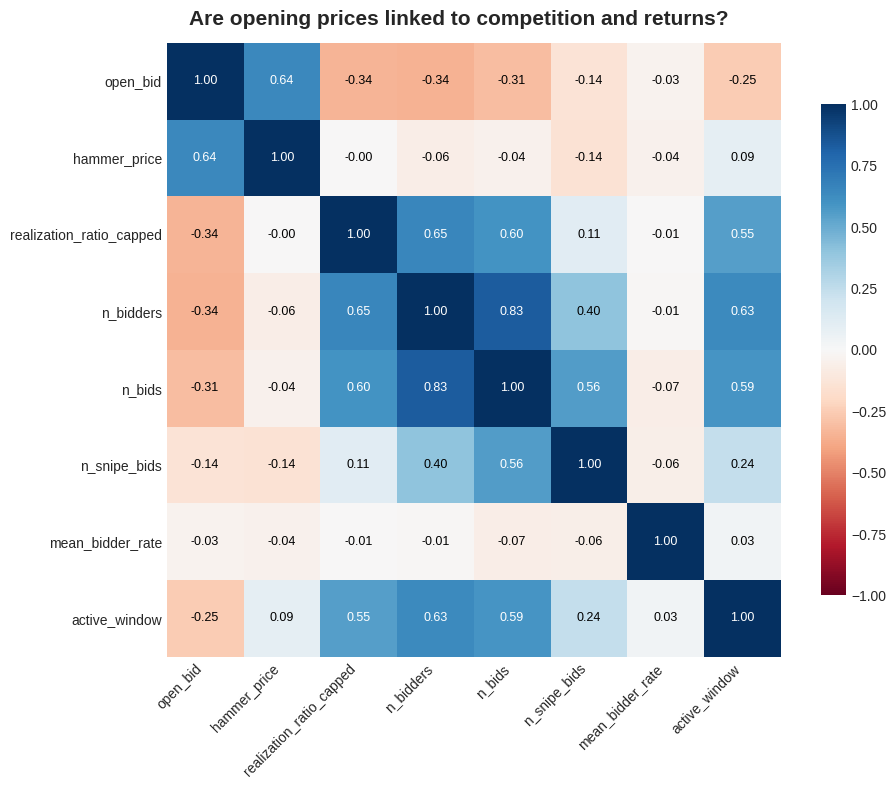

In [26]:
corr_cols = [
    "open_bid",
    "hammer_price",
    "realization_ratio_capped",
    "n_bidders",
    "n_bids",
    "n_snipe_bids",
    "mean_bidder_rate",
    "active_window"
]

corr_matrix = auction_level_df[corr_cols].corr()

fig8, ax = plt.subplots(figsize=(10, 8))
fig8.suptitle("Are opening prices linked to competition and returns?", fontsize=15, fontweight="bold")

im = ax.imshow(corr_matrix, cmap="RdBu", vmin=-1, vmax=1)

plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(corr_cols, fontsize=10)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center", va="center",
            fontsize=9,
            color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black"
        )

ax.grid(False)
plt.tight_layout()
plt.savefig("../img/08_correlation_matrix.png")
plt.show()

## Bidder engagement

This section uses `bidder_rate`, the cumulative net feedback score from the platform, as a proxy for experience. A score of 0 indicates a new user with no transaction history, while scores in the hundreds or thousands reflect highly active, long-standing participants.  

The goal is to understand whether specific item categories attract more experienced bidders and whether experience translates into a competitive advantage at the point of winning.

### Are experienced bidders drawn to specific categories?
Comparing the average mean and average max bidder rate across item categories reveals two distinct patterns.  
The `mean_bidder_rate` is broadly consistent across all three categories (31–41), suggesting that the typical participant pool is similarly experienced regardless of what is being auctioned.   
However, the gap between mean and max is large in every category indicating that a small number of highly experienced bidders participate alongside a much larger pool of casual ones. Counterintuitively, Xbox and Palm Pilot attract the highest max bidder rates (225 and 219.7), suggesting the presence of dedicated niche collectors, while Cartier draws a broader and more mixed audience.

In [27]:
bidder_rate_by_item = auction_level_df.groupby("item").agg(
    avg_mean_bidder_rate = ("mean_bidder_rate", "mean"),
    avg_max_bidder_rate  = ("max_bidder_rate", "mean")
).reset_index()

print(bidder_rate_by_item)

                  item  avg_mean_bidder_rate  avg_max_bidder_rate
0   Cartier wristwatch             40.725289           182.566176
1  Palm Pilot M515 PDA             31.026258           219.699708
2    Xbox game console             34.240353           225.006711


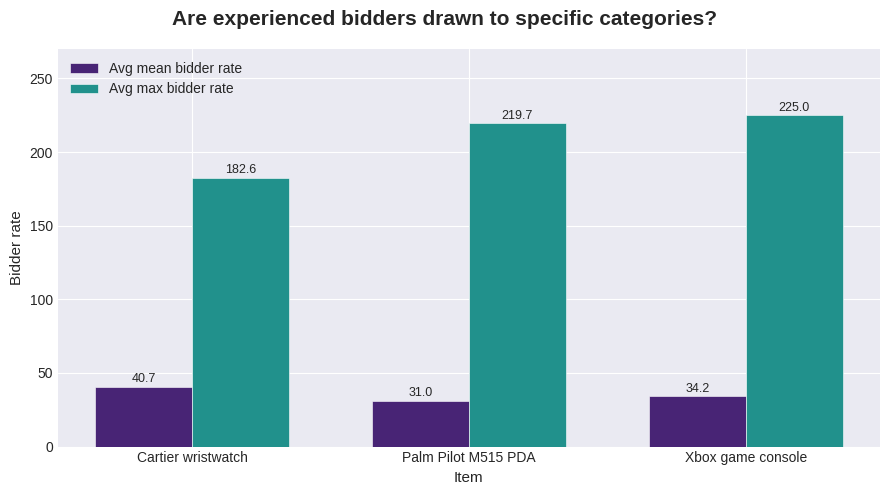

In [28]:
x = np.arange(len(bidder_rate_by_item))
width = 0.35

fig9, ax = plt.subplots(figsize=(9, 5))
fig9.suptitle("Are experienced bidders drawn to specific categories?", fontsize=15, fontweight="bold")

bars1 = ax.bar(x - width/2, bidder_rate_by_item["avg_mean_bidder_rate"], width,
               label="Avg mean bidder rate", color=ITEM_PALETTE[0], edgecolor="white", linewidth=0.4)
bars2 = ax.bar(x + width/2, bidder_rate_by_item["avg_max_bidder_rate"], width,
               label="Avg max bidder rate", color=ITEM_PALETTE[1], edgecolor="white", linewidth=0.4)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}",
            ha="center", va="bottom", fontsize=9
        )

ax.set_xticks(x)
ax.set_xticklabels(bidder_rate_by_item["item"], fontsize=10)
ax.set_xlabel("Item", fontsize=11)
ax.set_ylabel("Bidder rate", fontsize=11)
ax.set_ylim(0, bidder_rate_by_item["avg_max_bidder_rate"].max() * 1.2)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../img/09_bidder_rate_by_item.png", dpi=150, bbox_inches="tight")
plt.show()

### Do experienced bidders win more often?
The answer is category-dependent.  

In Cartier auctions, winners have a meaningfully higher average bidder rate than the auction mean (64.3 vs 40.7), suggesting that experience confers a real competitive advantage in high-value, contested auctions.  

In Palm Pilot auctions the two figures are virtually identical (31.0 vs 31.0), indicating that outcomes are decided by willingness to pay rather than bidding strategy.  

Xbox sits in between, with a modest gap of 4.5 points. 

This finding adds nuance to the correlation matrix result, where `mean_bidder_rate` showed near-zero correlation with most variables globally. That global signal masks meaningful category-level differences, experience matters in Cartier auctions specifically, and is largely irrelevant elsewhere.

In [29]:
bidder_experience = auction_level_df.groupby("item").agg(
    avg_mean_bidder_rate   = ("mean_bidder_rate", "mean"),
    avg_winner_bidder_rate = ("winner_bidder_rate", "mean")
).reset_index()

print(bidder_experience)

                  item  avg_mean_bidder_rate  avg_winner_bidder_rate
0   Cartier wristwatch             40.725289               64.316176
1  Palm Pilot M515 PDA             31.026258               31.041056
2    Xbox game console             34.240353               38.738255


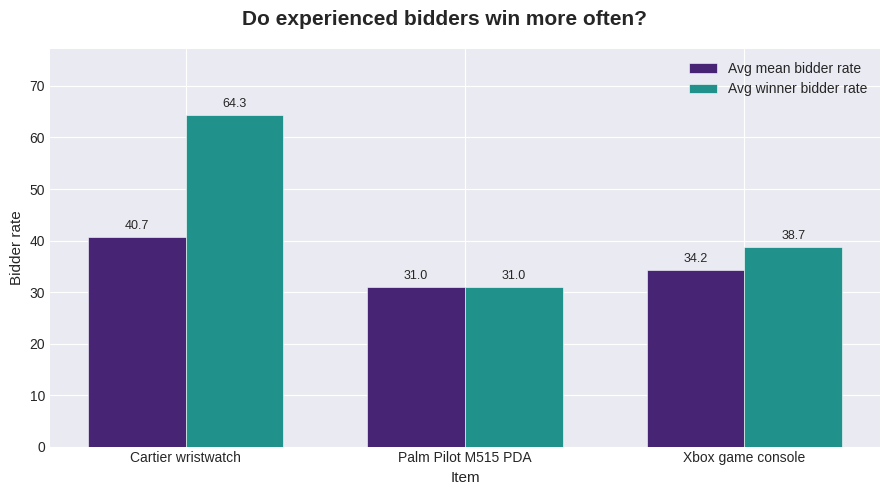

In [31]:
x = np.arange(len(bidder_experience))
width = 0.35

fig10, ax = plt.subplots(figsize=(9, 5))
fig10.suptitle("Do experienced bidders win more often?", fontsize=15, fontweight="bold")

bars1 = ax.bar(x - width/2, bidder_experience["avg_mean_bidder_rate"], width,
               label="Avg mean bidder rate", color=ITEM_PALETTE[0], edgecolor="white", linewidth=0.4)
bars2 = ax.bar(x + width/2, bidder_experience["avg_winner_bidder_rate"], width,
               label="Avg winner bidder rate", color=ITEM_PALETTE[1], edgecolor="white", linewidth=0.4)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}",
            ha="center", va="bottom", fontsize=9
        )

ax.set_xticks(x)
ax.set_xticklabels(bidder_experience["item"], fontsize=10)
ax.set_xlabel("Item", fontsize=11)
ax.set_ylabel("Bidder rate", fontsize=11)
ax.set_ylim(0, bidder_experience["avg_winner_bidder_rate"].max() * 1.2)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../img/10_winner_vs_mean_bidder_rate.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusions and recommendations

This analysis examined 628 auctions and 10.681 individual bids across three item categories (Cartier wristwatches, Palm Pilot M515 PDAs and Xbox game consoles) to identify data-driven insights across three areas: price discovery, temporal behaviour and bidder engagement. The findings are summarised below alongside actionable recommendations for an auction house.

### Key findings

**Price discovery**  
Lower opening prices consistently attract more bidders, generate more bids and produce higher realization ratios. Auctions opening below $50 attracted an average of 10.8 bidders and achieved a mean realization ratio of 36, compared to 1.5–2.2 for all higher bands. 
The relationship is confirmed quantitatively: opening price is negatively correlated with both competition (-0.34) and returns (-0.34). Conservative starting prices do not guarantee high returns, but they create the conditions for competitive escalation.

**Temporal behaviour**  
32.1% of all bids are placed in the final 5% of auction time, revealing a structural last-minute rush across all categories. Contrary to expectations, auctions won by a snipe bid do not produce higher hammer prices on average ($340 vs $388 for non-snipe wins), suggesting that sniping is a defensive strategy rather than a price-driving one.

**Bidder engagement**  
Bidder experience, measured by platform feedback rate, is not a universal predictor of winning. In Cartier auctions, winners are meaningfully more experienced than the average participant (64.3 vs 40.7), suggesting that expertise confers a real advantage in high-value contested auctions. In Palm Pilot and Xbox auctions, experience plays almost no role — outcomes are driven by willingness to pay.

### Recommendations  

1. **Set opening prices that are competitive but not artificially low.** High opening prices suppress participation while setting opening prices too close to zero inflates realization ratios mathematically, without necessarily reflecting genuine competitive demand. The sweet spot is a starting price that is low enough to attract a broad pool of bidders, while still reflecting a credible floor value for the item encouraging competitive escalation.

2. **Implement a soft-close mechanism**. With nearly one in three bids placed in the final 5% of auction time, extending the auction window when a last-minute bid is placed would encourage more competitive bidding throughout and reduce the advantage of pure sniping strategies.

3. **Segment marketing by buyer profile**. Cartier auctions attract a mixed audience where experienced bidders hold a significant advantage. Targeted outreach to seasoned collectors for high-value lots could increase competition and drive prices further. For lower-value categories, broad audience reach matters more than experience level.


*This project was conducted as an independent exploratory analysis. All findings are descriptive and based on a limited dataset of three item categories. Further validation on a larger and more diverse dataset would be required before operationalising any of these recommendations.*